In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import math

In [2]:
# Only needed once
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
data = pd.read_csv('fakenews_sample.csv')

data.head()

,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
0,0,141,awm.com,unreliable,http://awm.com/church-congregation-brings-gift...,Sometimes the power of Christmas will make you...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Church Congregation Brings Gift to Waitresses ...,Ruth Harris,NaN,[''],NaN,NaN,NaN
1,1,256,beforeitsnews.com,fake,http://beforeitsnews.com/awakening-start-here/...,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,Zurich Times,NaN,[''],NaN,NaN,NaN
2,2,700,cnnnext.com,unreliable,http://www.cnnnext.com/video/18526/never-hike-...,Never Hike Alone: A Friday the 13th Fan Film U...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Never Hike Alone - A Friday the 13th Fan Film ...,NaN,NaN,[''],Never Hike Alone: A Friday the 13th Fan Film ...,NaN,NaN
3,3,768,awm.com,unreliable,http://awm.com/elusive-alien-of-the-sea-caught...,"When a rare shark was caught, scientists were ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Elusive ‘Alien Of The Sea ‘ Caught By Scientis...,Alexander Smith,NaN,[''],NaN,NaN,NaN
4,4,791,bipartisanreport.com,clickbait,http://bipartisanreport.com/2018/01/21/trumps-...,Donald Trump has the unnerving ability to abil...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Trump’s Genius Poll Is Complete & The Results ...,Gloria Christie,NaN,[''],NaN,NaN,NaN


## Clean the Data

In [4]:
def clean_text(text):
    # 1. Håndter tomme værdier (vigtigt for det store datasæt)
    if pd.isna(text):
        return ""
    
    # 2. Gør alt til små bogstaver
    text = text.lower()

    # 3. Erstat URLs med et tag (bevarer information om at der var et link)
    text = re.sub(r'https?://\S+|www\.\S+', '<URL>', text)

    # 4. Erstat e-mails med et tag
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '<EMAIL>', text)

    # 5. Erstat datoer (f.eks. 13th) med et tag
    text = re.sub(r'[0-9]+[a-zA-Z]+', '<DATE>', text)

    # 6. Erstat resterende tal med et tag
    text = re.sub(r'[0-9]+', '<NUM>', text)
    
    # 7. Fjern specialtegn (behold kun bogstaver, tags og mellemrum)
    text = re.sub(r'[^a-z\s<>]', '', text)
    
    # 8. Fjern ekstra mellemrum, tabs og linjeskift
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

data["clean_content"] = data["content"].apply(clean_text)
data[["content", "clean_content"]].head()

,content,clean_content
0,Sometimes the power of Christmas will make you...,sometimes the power of christmas will make you...
1,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,awakening of <> strands of dna reconnecting wi...
2,Never Hike Alone: A Friday the 13th Fan Film U...,never hike alone a friday the <> fan film usa ...
3,"When a rare shark was caught, scientists were ...",when a rare shark was caught scientists were l...
4,Donald Trump has the unnerving ability to abil...,donald trump has the unnerving ability to abil...


In [5]:
data['tokens'] = data['clean_content'].apply(nltk.word_tokenize)
data[['clean_content', 'tokens']].head()

,clean_content,tokens
0,sometimes the power of christmas will make you...,"[sometimes, the, power, of, christmas, will, m..."
1,awakening of <> strands of dna reconnecting wi...,"[awakening, of, <, >, strands, of, dna, reconn..."
2,never hike alone a friday the <> fan film usa ...,"[never, hike, alone, a, friday, the, <, >, fan..."
3,when a rare shark was caught scientists were l...,"[when, a, rare, shark, was, caught, scientists..."
4,donald trump has the unnerving ability to abil...,"[donald, trump, has, the, unnerving, ability, ..."


In [6]:
# Store English stopwords into a variable
english_stopwords = set(stopwords.words('english'))
print(f"Number of stopwords: {len(english_stopwords)}")
print(list(english_stopwords)[:15]) # Display first 15 stopwords

data['filtered_tokens'] = data['tokens'].apply(lambda tokens: [word for word in tokens if word not in english_stopwords])
data[['tokens', 'filtered_tokens']].head()

Number of stopwords: 198
["isn't", 'before', 'why', 'more', 'itself', 'shan', 'was', 'weren', "you're", 're', "didn't", 'while', 'where', 'so', 'all']


,tokens,filtered_tokens
0,"[sometimes, the, power, of, christmas, will, m...","[sometimes, power, christmas, make, wild, wond..."
1,"[awakening, of, <, >, strands, of, dna, reconn...","[awakening, <, >, strands, dna, reconnecting, ..."
2,"[never, hike, alone, a, friday, the, <, >, fan...","[never, hike, alone, friday, <, >, fan, film, ..."
3,"[when, a, rare, shark, was, caught, scientists...","[rare, shark, caught, scientists, left, blunde..."
4,"[donald, trump, has, the, unnerving, ability, ...","[donald, trump, unnerving, ability, ability, c..."


In [7]:
# Liste over alle ord i alle artikler
all_words_list = [word for tokens_list in data['tokens'] for word in tokens_list]

# Sæt af unikke ord (vocab) og beregn vocab size
vocab = set(all_words_list)

# Længden af vocab
vocab_size = len(vocab)

print(f"Antal tokens i alt (alle ord i alle artikler): {len(all_words_list)}")
print(f"Vocabulary size (unikke ord): {vocab_size}")
print(f"10 ord i the vocab (bare lige for at se): {list(vocab)[:10]}")

Antal tokens i alt (alle ord i alle artikler): 173381
Vocabulary size (unikke ord): 16471
10 ord i the vocab (bare lige for at se): ['terrorism', 'outing', 'bullet', 'petition', 'damned', 'lobbies', 'xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx', 'strive', 'midaugust', 'ponder']


In [8]:
# Liste over alle ord i alle artikler
filtered_words_list = [word for tokens_list in data['filtered_tokens'] for word in tokens_list]

# Sæt af unikke ord (vocab) og beregn vocab size
vocab_filtered = set(filtered_words_list)

# Længden af vocab
filtered_vocab_size = len(vocab_filtered)

print(f"Antal tokens i alt (alle ord i alle artikler): {len(filtered_words_list)}")
print(f"Vocabulary size (unikke ord): {filtered_vocab_size}")
print(f"10 ord i the vocab (bare lige for at se): {list(vocab_filtered)[:10]}")

Antal tokens i alt (alle ord i alle artikler): 100005
Vocabulary size (unikke ord): 16339
10 ord i the vocab (bare lige for at se): ['terrorism', 'outing', 'bullet', 'petition', 'damned', 'lobbies', 'xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx', 'strive', 'midaugust', 'ponder']


In [9]:
ps = PorterStemmer()

# Anvend stemming på de filtrerede tokens og gem det i en ny kolonne 'stemmed'
data['stemmed'] = data['filtered_tokens'].apply(
    lambda x: [ps.stem(w) if not w.startswith('<') else w for w in x]
)

# Liste over alle stemmede ord i alle artikler
all_stemmed_words = [word for sublist in data['stemmed'] for word in sublist]

# Sæt af unikke stemmede ord (vocab) og beregn vocab size
vocab_stemmed = set(all_stemmed_words)
vocab_stemmed_size = len(vocab_stemmed)

# Reduktion efter stopwords i forhold til baseline
reduction_stop = (1 - (filtered_vocab_size / vocab_size)) * 100

# Reduktion efter stemming i forhold til efter stopwords
reduction_stem = (1 - (vocab_stemmed_size / filtered_vocab_size)) * 100

# PRINT RESULTATER 
print(f"\n--- STATISTIK FOR TASK 1 ---")
print(f"Oprindelig Vocab Size: {vocab_size}")
print(f"Vocab Size efter Stopwords: {filtered_vocab_size} (Reduktion: {reduction_stop:.2f}%)")
print(f"Vocab Size efter Stemming: {vocab_stemmed_size} (Reduktion: {reduction_stem:.2f}%)")


--- STATISTIK FOR TASK 1 ---
Oprindelig Vocab Size: 16471
Vocab Size efter Stopwords: 16339 (Reduktion: 0.80%)
Vocab Size efter Stemming: 10926 (Reduktion: 33.13%)


In [10]:
# Frequency of the ten most common word before and after stemming
from collections import Counter
most_common_before = Counter(all_words_list).most_common(12)
most_common_after = Counter(all_stemmed_words).most_common(12)
print("\n10 mest almindelige ord før stemming:")
for word, freq in most_common_before:
    print(f"{word}: {freq}")

print("\n10 mest almindelige ord efter stemming:")
for word, freq in most_common_after:
    print(f"{word}: {freq}")


10 mest almindelige ord før stemming:
the: 9487
of: 4965
to: 4889
and: 4698
a: 3385
>: 3189
<: 3183
in: 3109
is: 2317
that: 2203
for: 1553
it: 1344

10 mest almindelige ord efter stemming:
>: 3189
<: 3183
one: 463
us: 447
like: 406
time: 393
peopl: 387
state: 366
trump: 348
use: 322
would: 321
market: 296


In [11]:
# Split the data (80, 10, 10)
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 200
Validation size: 25
Test size: 25


## Part 2

In [12]:
# Find unique label types (column: type)
unique_labels = data['type'].unique()
print(f"Unique label types: {unique_labels}")

# count of each label type
label_counts = data['type'].value_counts()
print("\nLabel counts:")
print(label_counts)

Unique label types: ['unreliable' 'fake' 'clickbait' 'conspiracy' 'reliable' 'bias' 'hate'
 'junksci' 'political' nan 'unknown']

Label counts:
type
fake          155
conspiracy     31
political      23
unreliable      6
junksci         6
bias            6
unknown         6
reliable        3
clickbait       1
hate            1
Name: count, dtype: int64


In [13]:
# Group labels (type) into reliable and unreliable
train_data['Labels'] = train_data['type'].apply(lambda x: 'news' if x == 'reliable' else 'fake news')
val_data['Labels'] = val_data['type'].apply(lambda x: 'news' if x == 'reliable' else 'fake news')

unique_labels_grouped = train_data['Labels'].unique()
print(f"\nUnique label types after grouping: {unique_labels_grouped}")
grouped_labels_counts = train_data['Labels'].value_counts()
print("\nGrouped label counts:")
print(grouped_labels_counts)


Unique label types after grouping: ['fake news' 'news']

Grouped label counts:
Labels
fake news    198
news           2
Name: count, dtype: int64


In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

In [15]:
train_texts = train_data['stemmed'].apply(lambda x: " ".join(x))
val_texts = val_data['stemmed'].apply(lambda x: " ".join(x))

y_train = train_data['Labels']
y_val = val_data['Labels']

vectorizer = CountVectorizer(vocabulary= vocab_stemmed, max_features=10000)

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

   fake news       1.00      1.00      1.00        25

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [16]:
# Combine titel and stemmed content into one text feature
train_combined_text = train_data['title'].fillna('') + " " + train_data['stemmed'].apply(lambda x: " ".join(x))
val_combined_text = val_data['title'].fillna('') + " " + val_data['stemmed'].apply(lambda x: " ".join(x))

X_train_text = vectorizer.fit_transform(train_combined_text)
X_val_text = vectorizer.transform(val_combined_text)

# Make meta-data feature
encoder = OneHotEncoder(handle_unknown='ignore')
X_train_domain = encoder.fit_transform(train_data[['domain']].fillna('unknown'))
X_val_domain = encoder.transform(val_data[['domain']].fillna('unknown'))

# Stack features together
X_train_final = hstack([X_train_text, X_train_domain])
X_val_final = hstack([X_val_text, X_val_domain])

meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(X_train_final, y_train)

y_pred_meta = meta_model.predict(X_val_final)
print(classification_report(y_val, y_pred_meta))

              precision    recall  f1-score   support

   fake news       1.00      1.00      1.00        25

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



## Part 3

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
# make tfidf vectorizer
tfidf = TfidfVectorizer(max_features=10000) # ???
train_tfidf = tfidf.fit_transform(train_texts)
val_tfidf = tfidf.transform(val_texts)  

# Make encoder to transofrm y_train and y_val (1, 0)
encoder = LabelEncoder()
en_train = encoder.fit_transform(y_train)
en_val = encoder.transform(y_val)

In [19]:
# Make Neural network
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    batch_size='auto',
    early_stopping=True,
    random_state=42,
    verbose=True
)

# training
nn_model.fit(train_tfidf, en_train)

Iteration 1, loss = 0.64567583
Validation score: 1.000000
Iteration 2, loss = 0.61582674
Validation score: 1.000000
Iteration 3, loss = 0.58840242
Validation score: 1.000000
Iteration 4, loss = 0.56135168
Validation score: 1.000000
Iteration 5, loss = 0.53380008
Validation score: 1.000000
Iteration 6, loss = 0.50598092
Validation score: 1.000000
Iteration 7, loss = 0.47826526
Validation score: 1.000000
Iteration 8, loss = 0.45100707
Validation score: 1.000000
Iteration 9, loss = 0.42456148
Validation score: 1.000000
Iteration 10, loss = 0.39913277
Validation score: 1.000000
Iteration 11, loss = 0.37485285
Validation score: 1.000000
Iteration 12, loss = 0.35179029
Validation score: 1.000000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [20]:
# prediction
nn_pred = nn_model.predict(val_tfidf)
print(classification_report(en_val, nn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



## Part 4

In [ ]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay

In [22]:
# Running the predictions models on test fake news dataset
test_data['Label'] = test_data['type'].apply(lambda x: 'news' if x == 'reliable' else 'fake news')
y_test = test_data['Label']

test_text = test_data['stemmed'].apply(lambda x: " ".join(x))

X_test = vectorizer.transform(test_text)
test_log = model.predict(X_test)

print(classification_report(y_test, test_log))

              precision    recall  f1-score   support

   fake news       0.96      1.00      0.98        24
        news       0.00      0.00      0.00         1

    accuracy                           0.96        25
   macro avg       0.48      0.50      0.49        25
weighted avg       0.92      0.96      0.94        25



c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

TN: 24, FP: 0, FN: 1, TP: 0


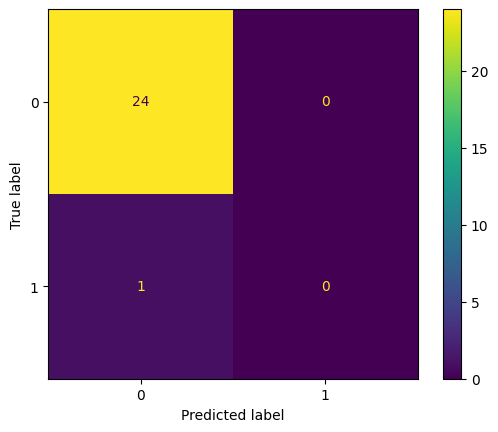

In [36]:
test_log_cm = confusion_matrix(y_test, test_log)
print(f"TN: {test_log_cm[0][0]}, FP: {test_log_cm[0][1]}, FN: {test_log_cm[1][0]}, TP: {test_log_cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=test_log_cm)
disp.plot()

In [24]:
test_text = test_data['stemmed'].apply(lambda x: " ".join(x))

X_test = tfidf.transform(test_text)
X_test = X_test.toarray()  # ????

test_nn = nn_model.predict(X_test)

test_labels = encoder.transform(y_test)

print(classification_report(test_labels, test_nn))

c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       0.00      0.00      0.00         1

    accuracy                           0.96        25
   macro avg       0.48      0.50      0.49        25
weighted avg       0.92      0.96      0.94        25



c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


TN: 24, FP: 0, FN: 1, TP: 0


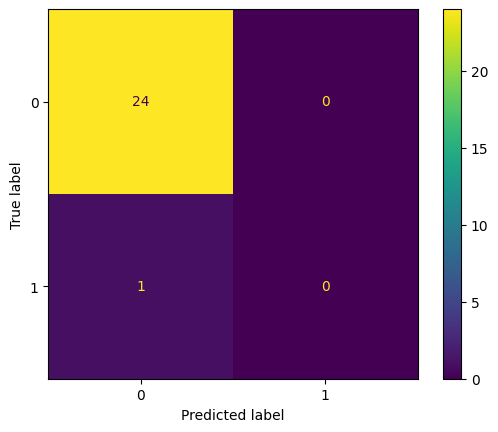

In [35]:
test_nn_cm = confusion_matrix(test_labels, test_nn)
print(f"TN: {test_nn_cm[0][0]}, FP: {test_nn_cm[0][1]}, FN: {test_nn_cm[1][0]}, TP: {test_nn_cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=test_nn_cm)
disp.plot()

In [26]:
# Running the predictions models on LIAR
liar_columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker job', 
    'state info', 'party affiliation', 'barelytrue_counts', 'false_counts', 
    'halftrue_counts', 'mostlytrue_counts', 'pantsonfire_counts', 'context'
]

liar = pd.read_csv('test.tsv', sep='\t', names=liar_columns)

liar['new_label'] = liar['label'].apply(lambda x: 'news' if x == 'true' else 'fake news')

liar.head()


,id,label,statement,subject,speaker,speaker job,state info,party affiliation,barelytrue_counts,false_counts,halftrue_counts,mostlytrue_counts,pantsonfire_counts,context,new_label
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,news
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,fake news
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,fake news
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show,fake news
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,fake news


In [27]:
liar['cleaned'] = liar['statement'].apply(clean_text)
liar['stemmed'] = liar['cleaned'].apply( lambda x: " ".join([ps.stem(word) for word in x.split()]))

liar.head()

,id,label,statement,subject,speaker,speaker job,state info,party affiliation,barelytrue_counts,false_counts,halftrue_counts,mostlytrue_counts,pantsonfire_counts,context,new_label,cleaned,stemmed
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,news,building a wall on the usmexico border will ta...,build a wall on the usmexico border will take ...
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,fake news,wisconsin is on pace to double the number of l...,wisconsin is on pace to doubl the number of la...
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,fake news,says john mccain has done nothing to help the ...,say john mccain ha done noth to help the vet
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show,fake news,suzanne bonamici supports a plan that will cut...,suzann bonamici support a plan that will cut c...
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,fake news,when asked by a reporter whether hes at the ce...,when ask by a report whether he at the center ...


In [28]:
y_liar = liar['new_label']

X_liar = vectorizer.transform(liar['stemmed'])
liar_log = model.predict(X_liar)

print(classification_report(y_liar, liar_log))

              precision    recall  f1-score   support

   fake news       0.84      1.00      0.91      1059
        news       0.00      0.00      0.00       208

    accuracy                           0.84      1267
   macro avg       0.42      0.50      0.46      1267
weighted avg       0.70      0.84      0.76      1267



c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

TN: 1059, FP: 0, FN: 208, TP: 0


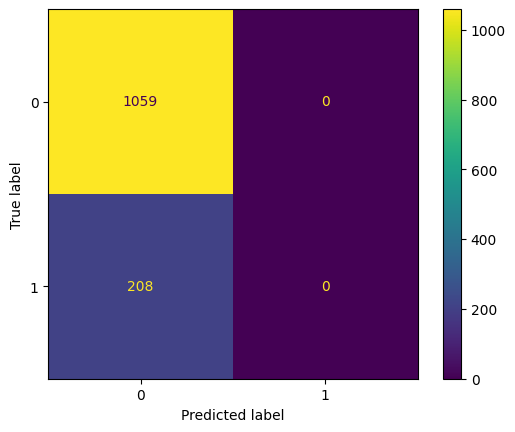

In [34]:
liar_log_cm = confusion_matrix(y_liar, liar_log)
print(f"TN: {liar_log_cm[0][0]}, FP: {liar_log_cm[0][1]}, FN: {liar_log_cm[1][0]}, TP: {liar_log_cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=liar_log_cm)
disp.plot()

In [30]:
tfidf_liar = tfidf.transform(liar['stemmed'])
liar_nn = nn_model.predict(tfidf_liar)

liar_labels = encoder.transform(y_liar)

print(classification_report(liar_labels, liar_nn))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1059
           1       0.00      0.00      0.00       208

    accuracy                           0.84      1267
   macro avg       0.42      0.50      0.46      1267
weighted avg       0.70      0.84      0.76      1267



c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

TN: 1059, FP: 0, FN: 208, TP: 0


AttributeError: module 'matplotlib' has no attribute 'title'

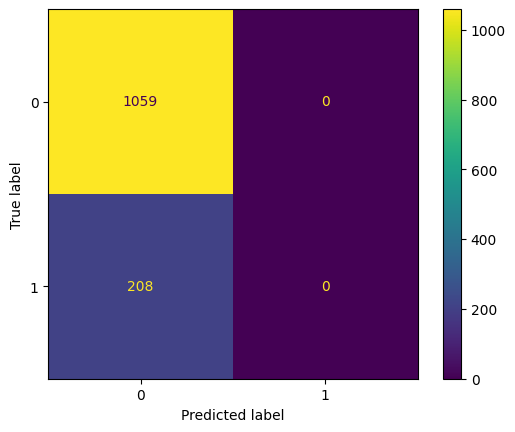

In [33]:
liar_nn_cm = confusion_matrix(liar_labels, liar_nn)
print(f"TN: {liar_nn_cm[0][0]}, FP: {liar_nn_cm[0][1]}, FN: {liar_nn_cm[1][0]}, TP: {liar_nn_cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=liar_nn_cm)
disp.plot()

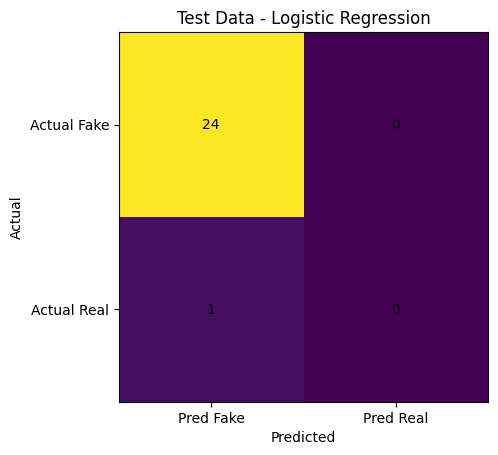

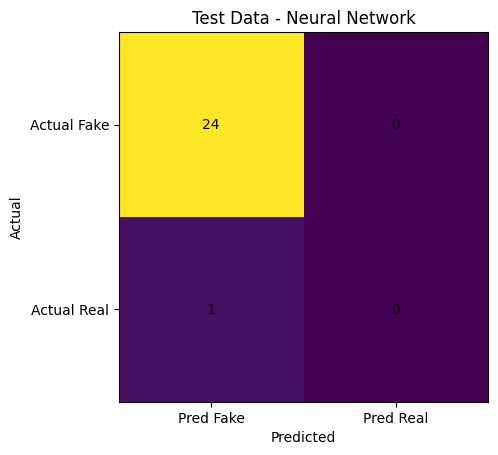

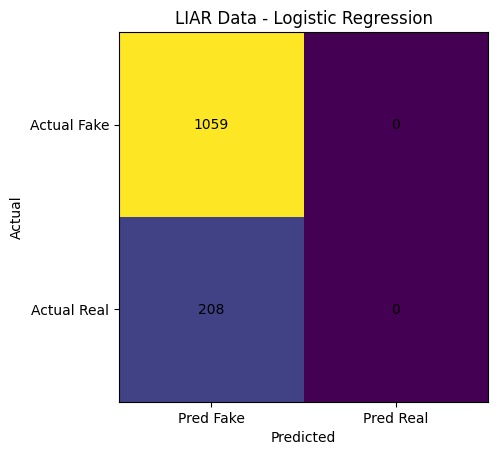

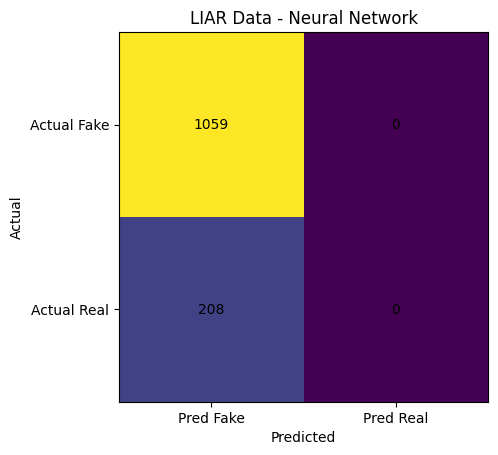

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cm(cm, title):
    plt.figure()
    plt.imshow(cm)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xticks([0,1], ['Pred Fake', 'Pred Real'])
    plt.yticks([0,1], ['Actual Fake', 'Actual Real'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()


# Test dataset
plot_cm(test_log_cm, "Test Data - Logistic Regression")
plot_cm(test_nn_cm, "Test Data - Neural Network")

# LIAR dataset
plot_cm(liar_log_cm, "LIAR Data - Logistic Regression")
plot_cm(liar_nn_cm, "LIAR Data - Neural Network")

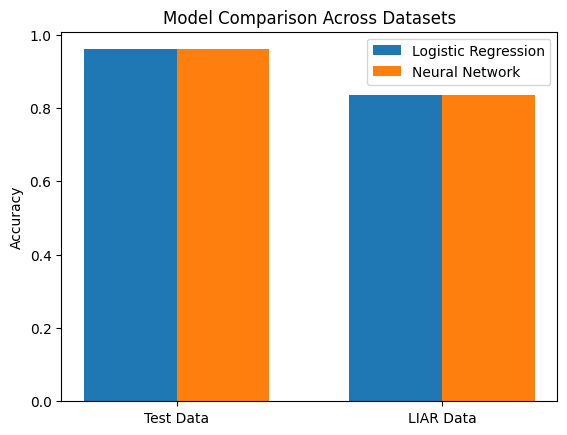

In [38]:
def get_accuracy(cm):
    return (cm[0][0] + cm[1][1]) / np.sum(cm)

labels = ['Test Data', 'LIAR Data']

log_acc = [
    get_accuracy(test_log_cm),
    get_accuracy(liar_log_cm)
]

nn_acc = [
    get_accuracy(test_nn_cm),
    get_accuracy(liar_nn_cm)
]

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, log_acc, width, label='Logistic Regression')
plt.bar(x + width/2, nn_acc, width, label='Neural Network')

plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Model Comparison Across Datasets')
plt.legend()

plt.show()